<a href="https://colab.research.google.com/github/MuizSarwar/Deep-Learning-study-materials-/blob/main/Fashion_mnist_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [4]:
#random seeds for reproducibility
torch.manual_seed(42)

In [5]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [7]:
df = pd.read_csv("/content/fmnist_small.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


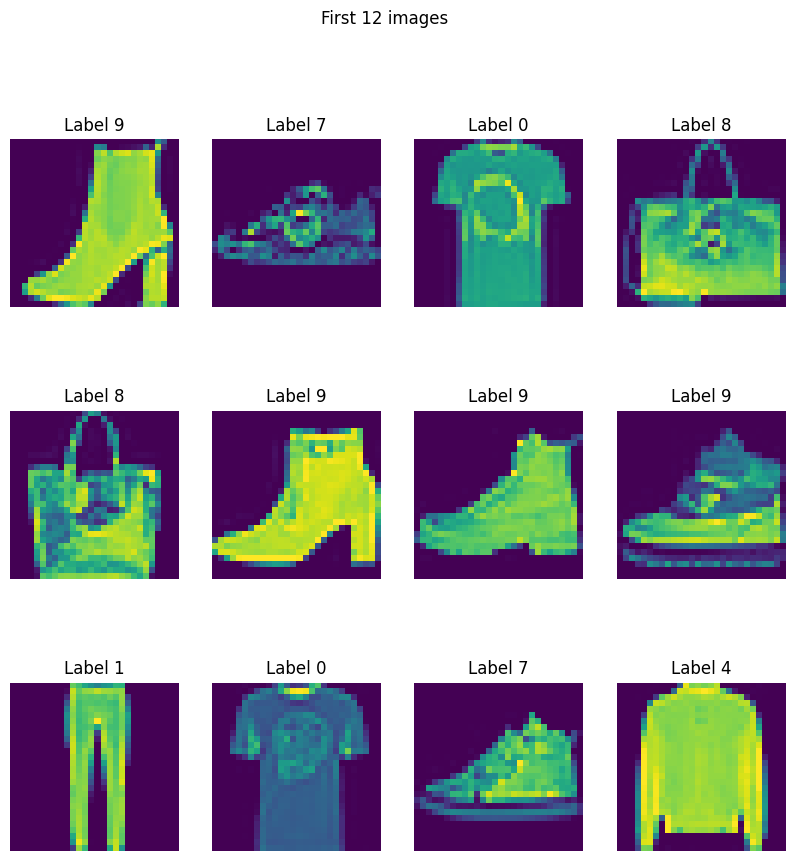

In [8]:
#create a 3x4 grid of images
fig,axes = plt.subplots(3,4,figsize=(10,10))
fig.suptitle("First 12 images")


#plot the first 12 image from dataset
for i,ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f"Label {df.iloc[i,0]}")

In [9]:
#train test split
X = df.iloc[:,1:].values
y = df.iloc[:,0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
#Scaling
X_train = X_train/255.0
X_test = X_test/255.0

#Dataset and Dataloader

In [11]:
class Customdataset(Dataset):
  def __init__(self,features,labels):
    self.features = torch.tensor(features,dtype=torch.float32)
    self.labels = torch.tensor(labels,dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index],self.labels[index]

In [12]:
train_dataset = Customdataset(X_train,y_train)
test_dataset = Customdataset(X_test,y_test)

In [13]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

##Define Model

In [14]:
class FmnistModel(nn.Module):
  def __init__(self,features_num):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(features_num,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10)
    )

  def forward(self,features):
    return self.model(features)

In [15]:
#Learning Rate & Epoch
epochs = 100
learning_rate = 0.1

In [16]:
#Instantiate model
model = FmnistModel(X_train.shape[1])
model = model.to(device)

#losss function
criterion = nn.CrossEntropyLoss()

#Optimizer
optimizer = optim.SGD(model.parameters(),lr=learning_rate)

##Training Loop

In [17]:
for epoch in range(epochs):
  epoch_loss = 0
  for batch_features,batch_labels in train_loader:
     # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    #forward pass
    outputs = model(batch_features)
    #calculate loss
    loss = criterion(outputs,batch_labels)
    #back pass
    loss.backward()
    #update grads
    optimizer.step()
    #reset
    optimizer.zero_grad()
    epoch_loss += loss.item()

  avg_epoch_loss = epoch_loss / len(train_loader)
  print(f"{epoch+1} loss --> {avg_epoch_loss}")

1 loss --> 1.3216368587811789
2 loss --> 0.779336541891098
3 loss --> 0.6427524608373641
4 loss --> 0.5751657414436341
5 loss --> 0.5278772541880608
6 loss --> 0.49531100074450174
7 loss --> 0.46192684868971506
8 loss --> 0.4355265040695667
9 loss --> 0.41890643616517387
10 loss --> 0.39741520086924237
11 loss --> 0.38665723502635957
12 loss --> 0.37127780785163245
13 loss --> 0.34902072985967
14 loss --> 0.3476298343638579
15 loss --> 0.315855147143205
16 loss --> 0.31195787360270816
17 loss --> 0.2958236853778362
18 loss --> 0.2882651568452517
19 loss --> 0.2712535865108172
20 loss --> 0.2599384474754334
21 loss --> 0.2577110414206982
22 loss --> 0.24670669116079808
23 loss --> 0.23920624203979968
24 loss --> 0.22601549635330836
25 loss --> 0.2235869560142358
26 loss --> 0.21268803268671035
27 loss --> 0.21945507449408372
28 loss --> 0.21106705954919258
29 loss --> 0.18709857530891896
30 loss --> 0.18914740840593974
31 loss --> 0.185476362456878
32 loss --> 0.18503415880103907
33 los

#Evaluation

In [18]:
model.eval()

total,correct = 0,0

with torch.no_grad():
  for batch_features,batch_labels in test_loader:
    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)
    _,predicted = torch.max(outputs,1)
    correct += (batch_labels == predicted).sum().item()
    total += batch_labels.shape[0]


print(f"Accuracy {correct/total}")

Accuracy 0.8241666666666667
